
Language distribution:
languages_list
English       81549
Other         39160
French         9755
Spanish        6635
German         5409
Italian        4150
Russian        3791
Japanese       2330
Chinese        1715
Arabic          903
Czech           869
Portuguese      790
Swedish         687
Korean          636
Polish          622
Hindi           472
Turkish         320
Norwegian       264
Danish          216
Finnish         198
Dutch           177
Name: count, dtype: int64


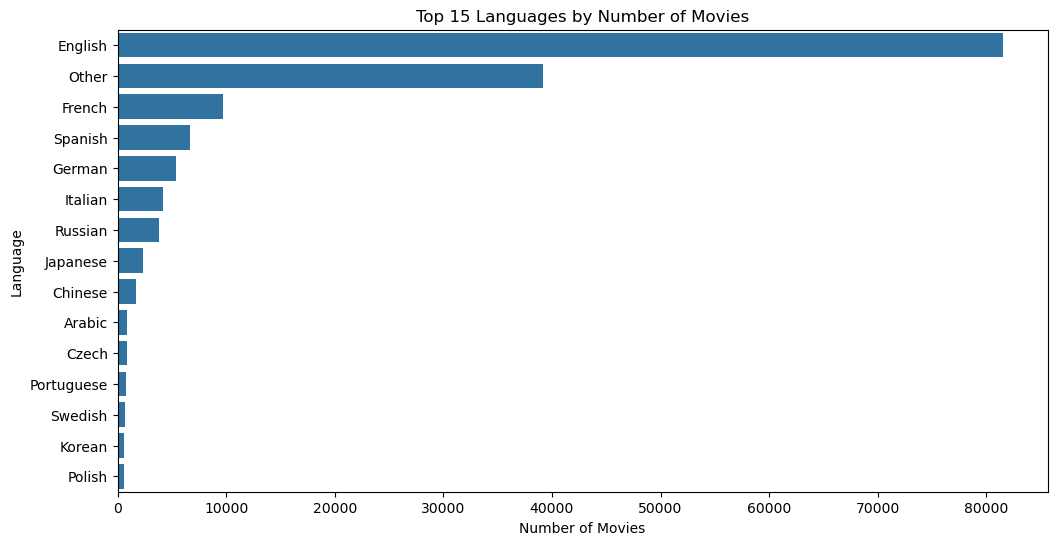


Identified Niche Languages (less than 1% of total movies):
[]

Average rating per language:
languages_list
Polish        3.672830
Turkish       3.623438
Arabic        3.610188
Other         3.602669
German        3.569421
Czech         3.568470
French        3.548693
Danish        3.537037
Hindi         3.529661
Chinese       3.523615
Italian       3.523012
Spanish       3.500000
Swedish       3.489083
English       3.455665
Russian       3.444869
Korean        3.419025
Japanese      3.415236
Norwegian     3.270833
Dutch         3.254237
Portuguese    3.178481
Finnish       3.136364
Name: rating, dtype: float64


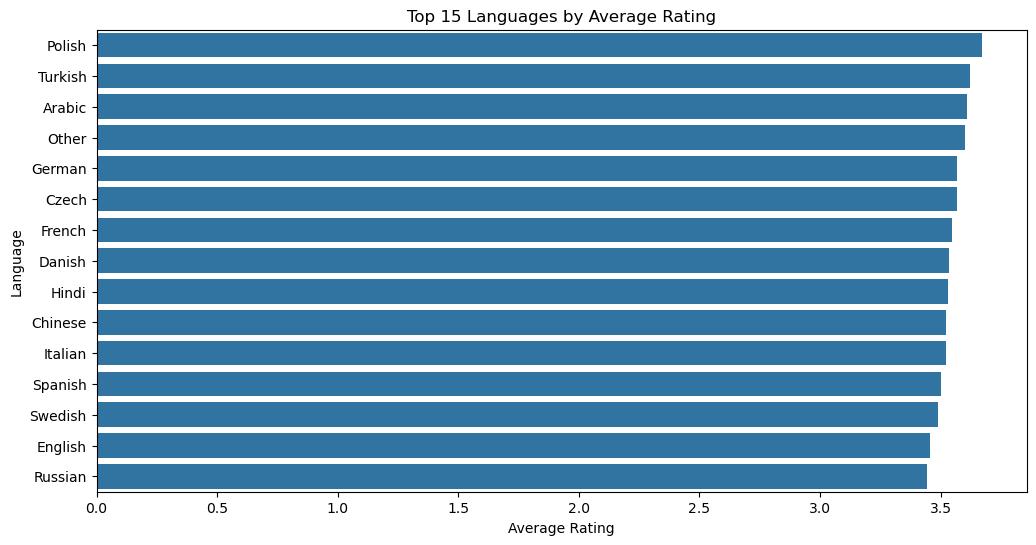


Average rating by language category:
language_category
Mainstream    3.505129
Name: rating, dtype: float64


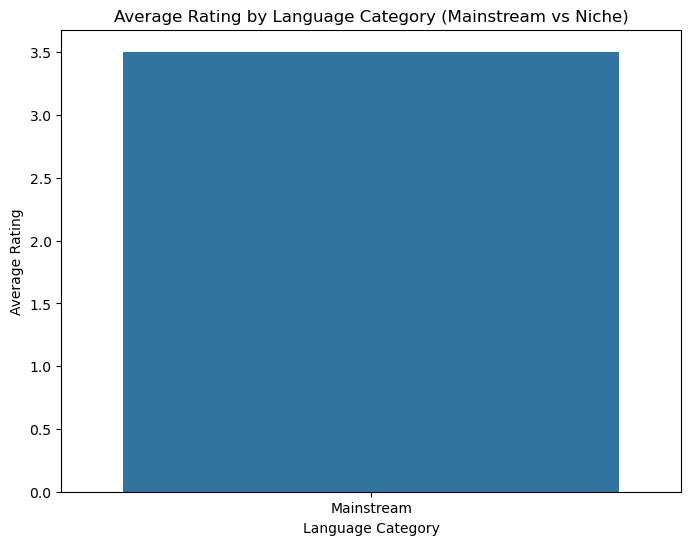


Number of ratings by language category:
language_category
Mainstream    160648
Name: rating, dtype: int64


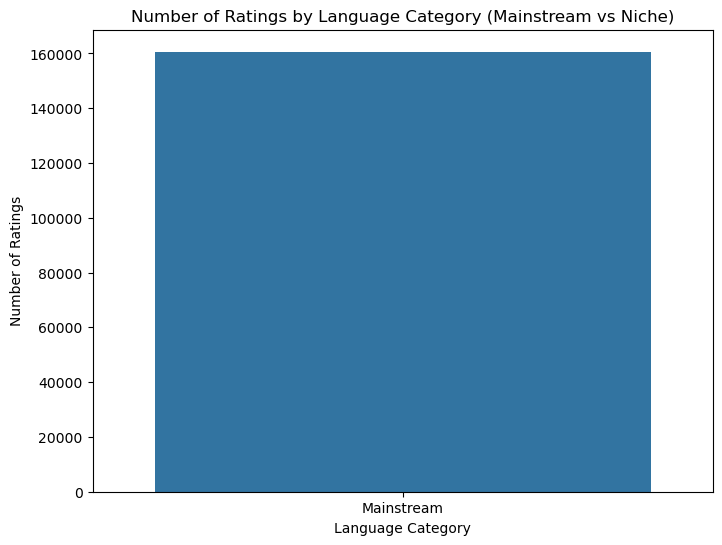

In [12]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import re  

ratings_with_providers = pd.read_csv('ratings_with_providers.csv')

movies_metadata = pd.read_csv('movies_metadata.csv', low_memory=False)

def extract_list(x, key):
    try:
        items = ast.literal_eval(x)
        return [item[key] for item in items] if items else []
    except (ValueError, SyntaxError, TypeError):
        return []

movies_metadata['genres_list'] = movies_metadata['genres'].apply(lambda x: extract_list(x, 'name'))
movies_metadata['production_countries_list'] = movies_metadata['production_countries'].apply(lambda x: extract_list(x, 'name'))
movies_metadata['languages_list'] = movies_metadata['spoken_languages'].apply(lambda x: extract_list(x, 'iso_639_1'))

def normalize_title(title):
    if isinstance(title, str):
        title = title.lower()
        title = re.sub(r'[^a-z0-9\s]', '', title)
        title = re.sub(r'\s+', ' ', title)
        return title.strip()
    else:
        return ''

movies_metadata['normalized_title'] = movies_metadata['title'].apply(normalize_title)

movies = pd.read_csv('movies.csv')
movies['clean_title'] = movies['title'].str.replace(r'\s*\(\d{4}\)', '', regex=True).str.strip()
movies['normalized_title'] = movies['clean_title'].apply(normalize_title)
movie_title_mapping = movies[['movieId', 'normalized_title']]

movies_metadata_subset = movies_metadata[['normalized_title', 'genres_list', 'production_countries_list', 'languages_list']]
movie_metadata_merged = pd.merge(
    movie_title_mapping,
    movies_metadata_subset,
    on='normalized_title',
    how='left'
)

ratings_with_providers = pd.merge(
    ratings_with_providers,
    movie_metadata_merged[['movieId', 'genres_list', 'production_countries_list', 'languages_list']],
    on='movieId',
    how='left'
)

# Analysis: Language Distribution

ratings_exploded_languages = ratings_with_providers.explode('languages_list')

language_code_to_name = {
    'en': 'English',
    'fr': 'French',
    'es': 'Spanish',
    'de': 'German',
    'it': 'Italian',
    'ja': 'Japanese',
    'ru': 'Russian',
    'zh': 'Chinese',
    'ko': 'Korean',
    'hi': 'Hindi',
    'pt': 'Portuguese',
    'nl': 'Dutch',
    'sv': 'Swedish',
    'da': 'Danish',
    'fi': 'Finnish',
    'no': 'Norwegian',
    'pl': 'Polish',
    'cs': 'Czech',
    'tr': 'Turkish',
    'ar': 'Arabic',
}

ratings_exploded_languages['languages_list'] = ratings_exploded_languages['languages_list'].map(language_code_to_name).fillna('Other')

language_counts = ratings_exploded_languages['languages_list'].value_counts()
print("\nLanguage distribution:")
print(language_counts)

# Plot the top 15 languages
top_languages = language_counts.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_languages.values, y=top_languages.index)
plt.xlabel('Number of Movies')
plt.ylabel('Language')
plt.title('Top 15 Languages by Number of Movies')
plt.show()

# -------------------------------------------------------------

total_movies = ratings_exploded_languages['movieId'].nunique()
niche_threshold = 0.01 * total_movies  # 1% of total movies

niche_languages = language_counts[language_counts < niche_threshold].index.tolist()
print(f"\nIdentified Niche Languages (less than 1% of total movies):")
print(niche_languages)

# -------------------------------------------------------------
# Analysis: Average Ratings per Language

average_rating_per_language = ratings_exploded_languages.groupby('languages_list')['rating'].mean().sort_values(ascending=False)
print("\nAverage rating per language:")
print(average_rating_per_language)

top_languages_rating = average_rating_per_language.head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_languages_rating.values, y=top_languages_rating.index)
plt.xlabel('Average Rating')
plt.ylabel('Language')
plt.title('Top 15 Languages by Average Rating')
plt.show()

# Compare Ratings Between Mainstream and Niche Languages

# classify languages as 'Mainstream' or 'Niche'
ratings_exploded_languages['language_category'] = ratings_exploded_languages['languages_list'].apply(
    lambda x: 'Niche' if x in niche_languages else 'Mainstream'
)

average_rating_per_language_category = ratings_exploded_languages.groupby('language_category')['rating'].mean()
print("\nAverage rating by language category:")
print(average_rating_per_language_category)

plt.figure(figsize=(8, 6))
sns.barplot(x=average_rating_per_language_category.index, y=average_rating_per_language_category.values)
plt.xlabel('Language Category')
plt.ylabel('Average Rating')
plt.title('Average Rating by Language Category (Mainstream vs Niche)')
plt.show()

# Analysis: Number of Ratings per Language Category

ratings_count_per_language_category = ratings_exploded_languages.groupby('language_category')['rating'].count()
print("\nNumber of ratings by language category:")
print(ratings_count_per_language_category)

plt.figure(figsize=(8, 6))
sns.barplot(x=ratings_count_per_language_category.index, y=ratings_count_per_language_category.values)
plt.xlabel('Language Category')
plt.ylabel('Number of Ratings')
plt.title('Number of Ratings by Language Category (Mainstream vs Niche)')
plt.show()
